---
title: Hidden Markov Model with Control (Part 1)
subtitle: Control a Roomba using Active Inference and RxInfer
author: Kobus Esterhuysen
date: '2024-05-10'
date-modified: last-modified
categories:
  - Bayesian Inference
  - Active Inference
  - RxInfer
  - Julia
image: HMMwithControl.png
format:
  html:
    toc: true
    toc-depth: 4
    toc-expand: true
    toc-title: TOC
    code-fold: false
---

In [1]:
#| hide
# BASED ON
  # HMMwithControl_PORT^v1.ipynb
  # Hidden Markov Model_ANNO^v5.ipynb
    
# DONE
# v2 starts ------------------------------------------------
# Upgrade to latest Julia (1.10.4)
# Upgrade to latest RxInfer (3.6.0)

# TODO


# Hidden Markov Model with Control (Part 1)

## 1 BUSINESS UNDERSTANDING

This is the first part of an effort to add control to the *Hidden Markov Model* RxInfer example. Eventually this work will be used in a more elaborate scheduling project making use of active inference.

In this part, we will simply be tracking a Roomba as it moves throughout a 3-bedroom apartment consisting of a master bedroom, a living room, and a bathroom. In addition, we start to wrap the original functionality with the usual structure:

- `create_envir()`
    - `execute()`
    - `observe()`
- `create_agent()`
    - `act()` [not yet]
    - `future()` [not yet]
    - `compute()`
    - `slide()` [not yet]

In the `compute()` function, which takes care of inference, we will estimate the $A$ and $B$ matrices. We also flipped the roles of these matrices to align with the neuroscience literature (rather than the engineering literature where $A$ is always used for system transitions).

Finally, we make use of the [Bert de Vries](https://www.tue.nl/en/research/researchers/bert-de-vries) naming conventions for variables.




In [1]:
versioninfo() ## Julia version

Julia Version 1.10.4
Commit 48d4fd48430 (2024-06-04 10:41 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)
Environment:
  JULIA_NUM_THREADS = 


In [3]:
import Pkg
Pkg.add(Pkg.PackageSpec(;name="RxInfer", version="3.6.0"))
Pkg.add(Pkg.PackageSpec(;name="Random"))
Pkg.add(Pkg.PackageSpec(;name="Plots", version="1.40.1"))
Pkg.add(Pkg.PackageSpec(;name="XLSX"))
Pkg.add(Pkg.PackageSpec(;name="DataFrames"))
Pkg.add(Pkg.PackageSpec(;name="BenchmarkTools"))
Pkg.add(Pkg.PackageSpec(;name="Distributions"))

using RxInfer, Random, BenchmarkTools, Distributions, Plots, XLSX, DataFrames

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.to

In [4]:
Pkg.status()

Status `~/.julia/environments/v1.10/Project.toml`
  [6e4b80f9] BenchmarkTools v1.5.0
  [a93c6f00] DataFrames v1.6.1
  [31c24e10] Distributions v0.25.111
⌃ [91a5bcdd] Plots v1.40.1
  [86711068] RxInfer v3.6.0
  [fdbf4ff8] XLSX v0.10.2
  [9a3f8284] Random
Info Packages marked with ⌃ have new versions available and may be upgradable.


## 2 DATA UNDERSTANDING

The data will consist of a time-series of 1-hot encoded position states. When the associated component of the state vector is a 1, the Roomba will be present in the associated room.

## 3 DATA PREPARATION

We will use the data from the simulation directly. There is no need to perform additional data preparation.

## 4 MODELING

### 4.1 Narrative

The next figure (from [Dr. Bert de Vries](https://www.tue.nl/en/research/researchers/bert-de-vries) at Eindhoven University of Technology) shows the interactions between the *agent* and the *environment*:

![](Interactions-AgtEnv.png)

The grey area shows the *markov blanket* of the agent. The interactions between the agent and environment can be summarized by:

$$\begin{aligned}
a_t &\sim q(u_t) \\
x_t &= y_t
\end{aligned}$$

This means that actions on the environment are sampled from the posterior over control signals. We will explain a bit more down below.

In general, we will have the following symbol conventions:

- $t$: time
- $k$: future time
- $l$: past time
- $x_t$: scalar random variable
- $\boldsymbol{x}_t$: sequence of scalar random variables
- $\mathbf{x}_t$: 1-hot encoded random variable

Global code variables will always be prefixed with an underscore '_'.

### 4.2 Core Elements

This section attempts to answer three important questions:

- What metrics are we going to track?
- What decisions do we intend to make?
- What are the sources of uncertainty?

The only metric we are interested in is the postition of the Roomba, i.e. in which of the 3 rooms it finds itself. 

There are no control/steering decisions to be made (yet). We are simply interested in the behavior of the Roomba.

There are two sources of uncertainty. The first has to do with the fact that the state transitions are not deterministic but rather stochastic. This will be captured in the transition matrix $B$. The second relates to observations. The Roomba does not always measure accurately the floor surface in a room. This uncertainty will be captured in the observation matrix $A$.

### 4.3 System-Under-Steer / Environment / Generative Process

First, in order to track the Roomba's movements using `RxInfer`, we need to come up with a model. Since we have a discrete set of rooms in the apartment, we can use a categorical distribution to represent the Roomba's position. There are three  rooms in the apartment, meaning we need three states in our categorical distribution. At time $t$, let's call the Roomba's true position $\tilde{s}_t$.

However, we also know that some rooms are more accessible than others, meaning the Roomba is more likely to move between these rooms - for example, it's rare to have a door directly between the bathroom and the master bedroom. We can encode this information using a transition matrix, which we will call $B$.

Our Roomba is equipped with a small camera that tracks the surface it is moving over. We will use this camera to obtain our observations since we know that there is

- hardwood floors in the master bedroom
- carpet in the living room, and
- tiles in the bathroom. 

However, this method is not foolproof, and sometimes the Roomba will make mistakes and mistake the hardwood floor for tiles or the carpet for hardwood. Don't be too hard on the little guy, it's just a Roomba after all.

At time $t$, we will call our observations $y_t$ and encode the mapping from the Roomba's position to the observations in a matrix we call $A$. $A$ also encodes the likelihood that the Roomba will make a mistake and get the wrong observation. This leaves us with the following model specification:

$$
\begin{aligned}
    s_t & \sim \mathcal{C}at(B s_{t-1}),\\
    x_t & \sim \mathcal{C}at(A s_t).\\
\end{aligned}
$$

This type of discrete state space model is known as a *Hidden Markov Model* or HMM for short. Our goal is to learn the matrices $A$ and $B$ so we can use them to track the whereabouts of our little cleaning agent.

In [6]:
_s̃₀ = [1.0, 0.0, 0.0] ## initial state

3-element Vector{Float64}:
 1.0
 0.0
 0.0

#### 4.3.1 State and Observation variables

The *state variables* represent *what we need to know*. The true state at time $t$ of the Roomba will be given by a 1-hot encoded vector 
$$\mathbf{\tilde{s}}_t=  (\mathcal{S})$$

where

$\mathcal{S} = \{ \mathrm{bedroom, livingroom, bathroom} \}$

- $[1, 0, 0]^T$: bedroom
- $[0, 1, 0]^T$: livingroom
- $[0, 0, 1]^T$: bathroom  

The 1-hot observation made by the Roomba at time $t$ will be given by

$$\mathbf{y}_t=  (\mathcal{O})$$

where

$\mathcal{O} = \{ \mathrm{hardwood, carpet, tiles} \}$

- $[1, 0, 0]^T$: hardwood
- $[0, 1, 0]^T$: carpet
- $[0, 0, 1]^T$: tiles

#### 4.3.2 Decision variables

There are no decisions to be made (yet). We are simply observing the behavior of the Roomba, i.e. there is no control/steering applied to the environment.

#### 4.3.3 Exogenous information / Autonomous variables

There are no exogenous information variables (yet). We may add some in followup parts, for example, having certain doors closed at random.

#### 4.3.4 Transition and Observation functions

The environment evolves accoring to

$$
\begin{aligned}
    \tilde{s}_t & \sim \mathcal{C}at(B \tilde{s}_{t-1}),\\
    y_t & \sim \mathcal{C}at(A \tilde{s}_t).\\
\end{aligned}
$$

where $\tilde{s}_t$ is the state and $y_t$ is the observation.


The agent/environment interaction may be expressed as:

$$
(y_t, \tilde{s_t}) = R_t(\tilde{s}_{t-1}, a_t, w_t)
$$

where

- $\tilde{s}_{t-1}$ is the previous state
- $a_t$ is the action [not yet]
- $w_t$ is the exogenous information / autonomous state [not yet]
- $y_t$ is the outcome or observation

##### Transition model $\tilde{B}$

|states $\tilde{s}_{t-1}$<br/>states $\tilde{s}_t$ |bed|living|bath  |
| ---                                              | --- | ---  |--- |
| bed                                              | 0.9| 0.0 | 0.1  |
| living                                           | 0.0| 0.9 | 0.1  |
| bath                                             | 0.1| 0.1 | 0.8  |

In [7]:
_B̃ = [ 
    0.9  0.0  0.1;
    0.0  0.9  0.1;
    0.1  0.1  0.8]

3×3 Matrix{Float64}:
 0.9  0.0  0.1
 0.0  0.9  0.1
 0.1  0.1  0.8

##### Observation model $\tilde{A}$

|states $\tilde{s}_{t}$<br/>observations $y_t$ |bed|living|bath   |
| ---                                          | --- | ---  |---  |
| bed                                          | 0.9| 0.05 | 0.05 |
| living                                       | 0.05| 0.9 | 0.05 |
| bath                                         | 0.05| 0.05 | 0.9 |

In [8]:
_Ã = [    
    0.9  0.05 0.05;
    0.05 0.9  0.05;
    0.05 0.05 0.9]

3×3 Matrix{Float64}:
 0.9   0.05  0.05
 0.05  0.9   0.05
 0.05  0.05  0.9

#### 4.3.5 Objective function

The objective function is such that the Bethe free energy (BFE) or Generalized free energy (GFE) is minimized. This aspect will be handled by the `RxInfer` Julia package.

#### 4.3.6 Implementation of the System-Under-Steer / Environment / Generative Process

In [9]:
## returns a one-hot encoding of a random sample from a categorical distribution
function rand_1hot_vec(rng, distribution::Categorical)
    K = ncategories(distribution)
    sample = zeros(K)
    drawn_category = rand(rng, distribution)
    sample[drawn_category] = 1.0
    return sample
end

rand_1hot_vec (generic function with 1 method)

In [10]:
function create_envir(; Ã, B̃, s̃₀, seed=42)
    rng = MersenneTwister(seed)
    s̃ₜ₋₁ = s̃₀
    s̃ₜ = s̃ₜ₋₁
    yₜ = s̃ₜ
    execute = () -> begin
        s̃ᵈⁱˢₜ = B̃*s̃ₜ₋₁ ##transition
        s̃ₜ = rand_1hot_vec(rng, Categorical(s̃ᵈⁱˢₜ))

        yᵈⁱˢₜ = Ã*s̃ₜ ##observation
        yₜ = rand_1hot_vec(rng, Categorical(yᵈⁱˢₜ))

        s̃ₜ₋₁ = s̃ₜ ##Reset state
    end

    observe = () -> begin
        return yₜ
    end
    
    return (execute, observe)
end

create_envir (generic function with 1 method)

In order to generate data to mimic the observations of the Roomba, we need to specify two things: the actual transition probabilities between the states (i.e., how likely is the Roomba to move from one room to another), and the observation distribution (i.e., what type of texture will the Roomba encounter in each room). We can then use these specifications to generate observations from our hidden Markov model (HMM).

To generate our observation data, we'll follow these steps:
1. Assume an initial state for the Roomba. For example, we can start the Roomba in the bedroom.
2. Determine where the Roomba went next by drawing from a Categorical distribution with the transition probabilities between the different rooms.
3. Determine the observation encountered in this room by drawing from a Categorical distribution with the corresponding observation probabilities.
4. Repeat steps 2-3 for as many samples as we want.


The following code implements this process and generates our observation data:

We will generate 600 data points to simulate 600 ticks of the Roomba moving through the apartment. `_ys` will contain the Roomba's measurements of the floor it's currently on, and `_s̃s` will contain information on the room the Roomba was actually in.

In [11]:
_N = 600
_s̃₀ = [1.0, 0.0, 0.0] ## initial state
(execute_sim, observe_sim) = create_envir(; 
    Ã=_Ã,
    B̃=_B̃,
    s̃₀=_s̃₀
)

_s̃s = Vector{Vector{Float64}}(undef, _N) ## States
_ys = Vector{Vector{Float64}}(undef, _N) ## Observations
for t = 1:_N
    _s̃s[t] = execute_sim() ## Hidden external states
    _ys[t] = observe_sim() ## Observe the current environmental outcome
end

In [12]:
_s̃s ## true states

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

In [13]:
_ys ## observations

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

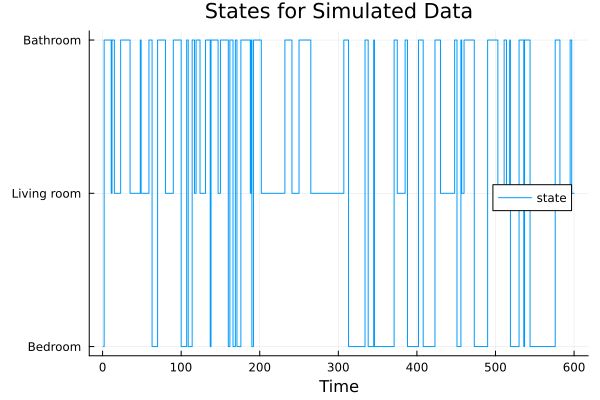

In [14]:
plot(title="States for Simulated Data")
plot!(
    argmax.(_s̃s), linetype=:steppre, linestyle=:solid, leg=:right, 
    label="state", xlabel="Time", yticks=([1,2,3,4], ["Bedroom", "Living room", "Bathroom"]))

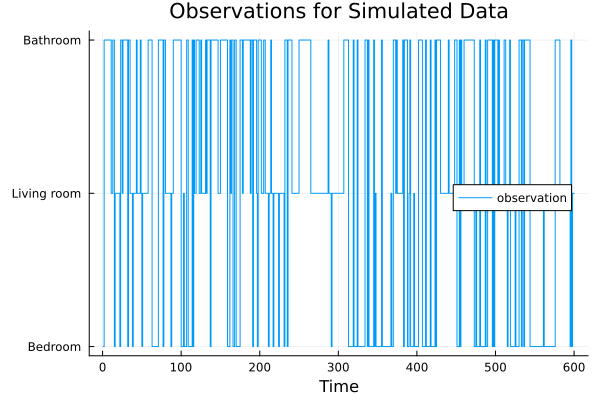

In [16]:
plot(title="Observations for Simulated Data")
plot!(
    argmax.(_ys), linetype=:steppre, linestyle=:solid, leg=:right, 
    label="observation", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))

### 4.4 Uncertainty Model

The uncertainty model is captured in the transition matrix $B$ and the observation matrix $A$.

### 4.5 Agent / Generative Model

The agent consists of:

- A free energy functional 
$F[q] = \mathbb E_q \left[\mathrm{log} \frac{q(z)}{p(x,z)}\right]$
where
    - $p(x, z) = \Pi_k p(x_k,z_k \mid z_{k-1})$ is a *generative* model with:
        - observations $\{x_k\}$
        - latent variables $\{z_k\} = \{ \{s_k\}, \{\theta_k\}, \{u_k\} \}$
        - $k$ is a time index
    - $q(z)$ is a *recognition* model
- A procedure to minimize the free energy $F[q]$

#### 4.5.1 State and Observation variables

On the agent's side, the state of the environment at time $t$ will be given by a 1-hot encoded vector $\mathbf s_t$. The *initial state prior* is given by
$$
p(\mathbf s_{0}) = \mathcal{Cat}(\mathbf s_{0} ∣ \mathbf d)
$$

where $\mathbf d$ parameterizes the categorical distribution of $\mathbf s_0$.

The observation made by the Roomba at time $t$ will be given by $\mathbf x_t$ where

- $\mathbf{x}_t = [1, 0, 0]^T$: hardwood
- $\mathbf{x}_t = [0, 1, 0]^T$: carpet
- $\mathbf{x}_t = [0, 0, 1]^T$: tiles


#### 4.5.2 Decision variables

There will be no decision variables (yet).

#### 4.5.3 Preference variables / Setpoints

There will be no preference variables (yet).

#### 4.5.4 Transition and Observation functions

The *transition function* is given by

$$\begin{aligned}
p(\mathbf s_k ∣ \mathbf s_{k-1}) &= \mathcal{Cat}(\mathbf s_k ∣ \mathbf B \mathbf s_{k-1})
\end{aligned}$$

where 

$\mathbf B \mathbf s_{k-1}$ parameterizes the categorical distribution of $\mathbf s_k$.

The *observation function* is given by

$$\begin{aligned}
p(\mathbf x_k ∣ \mathbf s_k) &= \mathcal{Cat}(\mathbf x_k ∣ \mathbf A \mathbf s_k)
\end{aligned}$$

where 

$\mathbf A \mathbf s_k$ parameterizes the categorical distribution of $\mathbf x_k$.

An entry in $A$ captures the probability of a specific *observation* given a specific *state*. Each column in $A$ contains a categorical distribution. A specific column is selected by multiplying with $\mathbf s$.

#### 4.5.5 Implementation of the Agent / Generative Model / Internal Model

We start by specifying a probabilistic model for the agent that describes the agent's internal beliefs over the external dynamics of the environment. Assuming the current time is $t$,

The generative model is defined as follows:

$$\begin{aligned} 
p(\boldsymbol{x}, \boldsymbol{s}) = 
\underbrace{p(s_{t-1})}_{\substack{\text{Initial} \\ \text{state}     \\ \text{prior}}} 
\prod_{k=t}^{t+T} 
\underbrace{p(x_k \mid s_k)}_{\substack{\text{Observation} \\ \text{model}}} \, 
\underbrace{p(s_k \mid s_{k-1}}_{\substack{\text{Transition}  \\ \text{model}}})
\end{aligned}$$

The generative model includes future time steps.

Next, we place 1-hot encodings on all random variables. Using regular bold font to  indicate the 1-hot encodings, and also setting $t=1$, we have:

$$\begin{aligned}
p(\boldsymbol{x}, \boldsymbol{s}) &\propto 
\underbrace{p(\mathbf s_0)}_{\substack{\text{Initial} \\ \text{state} \\ \text{prior}}} \prod_{k=1}^{T+1} 
\underbrace{p(\mathbf x_k \mid \mathbf s_k)}_{\substack{\text{Observation} \\ \text{model}}} \, 
\underbrace{p(\mathbf s_k \mid \mathbf s_{k-1}}_{\substack{\text{Transition} \\ \text{model}}})
\end{aligned}$$

where

$$\begin{aligned}
p(\mathbf s_{0})                          &= \mathcal{Cat}(\mathbf s_{0} ∣ \mathbf d) \\
p(\mathbf x_k ∣ \mathbf s_k)                &= \mathcal{Cat}(\mathbf x_k ∣ \mathbf A \mathbf s_k) \\
p(\mathbf s_k ∣ \mathbf s_{k-1}) &= \mathcal{Cat}(\mathbf s_k ∣ \mathbf B \mathbf s_{k-1}) \\
\end{aligned}$$

In general, if $\mathbf a$ is a 1-hot encoded random variable, and has a *categorical* (aka *multinoulli*) distribution, then

$$p(\mathbf a ∣ \boldsymbol{\rho}) = \mathcal{Cat}(\mathbf a ∣ \boldsymbol \rho) = \prod_{i} \rho_i^{a_i}$$

This means the $i$ th component of vector $\mathbf a$ selects the $i$ th component of the probability vector $\boldsymbol \rho$ of the distribution.

If the probability vector is
$\boldsymbol{\rho} = \begin{bmatrix} 0.05 \\ 0.05 \\ 0.50 \\ 0.10 \\ 0.10 \\ 0.20 \end{bmatrix}$
and the random variable $\mathbf a$ is
$\mathbf{a} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \\ 0 \\ 0 \end{bmatrix}$

then 
$$
\begin{aligned}
p(a=4 ∣ \boldsymbol{\rho}) &= \prod_{i} \rho_i^{a_i} \\
                            &= (0.05^0)(0.05^0)(0.50^0)(0.10^1)(0.10^0)(0.20^0) \\
                            &= 0.10
\end{aligned}
$$

Now it is time to build our model. As mentioned earlier, we will use Categorical distributions for the states and observations. To learn the $A$ and $B$ matrices we can use `MatrixDirichlet` priors. 

For the $B$-matrix, since we have no apriori idea how the roomba is actually going to move we will assume that it moves randomly. We can represent this by filling our `MatrixDirichlet` prior on $B$ with ones. Remember that this will get updated once we start learning, so it's fine if our initial guess is not quite accurate.

As for the observations, we have good reason to trust our Roomba's measurements. To represent this, we will add large values to the diagonal of our prior on $A$. However, we also acknowledge that the Roomba is not infallible, so we will add some noise on the off-diagonal entries.

Since we will use Variational Inference, we also have to specify inference constraints. We will use a structured variational approximation to the true posterior distribution, where we decouple the variational posterior over the states (`q(s_0, s)`) from the posteriors over the transition matrices (`q(A)` and `q(B)`). This dependency decoupling in the approximate posterior distribution ensures that inference is tractable. Let's build the model!

In [17]:
@model function hidden_markov_model(x, T)
    B ~ MatrixDirichlet(ones(3, 3))
    A ~ MatrixDirichlet([10.0 1.0 1.0; 
                         1.0 10.0 1.0; 
                         1.0 1.0 10.0 ])    
    s₀ ~ Categorical(fill(1.0/3.0, 3))
    ## s = randomvar(T)
    ## x = datavar(Vector{Float64}, T)
    
    sₖ₋₁ = s₀
    ## for k in eachindex(x)
    for k in 1:T
        s[k] ~ Transition(sₖ₋₁, B)
        x[k] ~ Transition(s[k], A)
        sₖ₋₁ = s[k]
    end
end

@constraints function hidden_markov_model_constraints()
    q(s₀, s, A, B) = q(s₀, s)q(A)q(B)
end

hidden_markov_model_constraints (generic function with 1 method)

Next, we define the agent and the time-stepping procedure.

In [18]:
function create_agent(; T=20, s₀, ys)
    compute = (ŷₜ::Vector{Float64}) -> begin
        imarginals = @initialization begin
            q(A) = vague(MatrixDirichlet, 3, 3)
            q(B) = vague(MatrixDirichlet, 3, 3) 
            q(s) = vague(Categorical, 3)
        end
        result = infer(
            ## model=hidden_markov_model(),
            model=hidden_markov_model(T=T),
            data=(x=ys,),
            constraints=hidden_markov_model_constraints(),
            ## initmarginals = ( 
            ##     A=vague(MatrixDirichlet, 3, 3), 
            ##     B=vague(MatrixDirichlet, 3, 3), 
            ##     s=vague(Categorical, 3)),
            initialization=imarginals,
            returnvars = (    
                A=KeepLast(),
                B=KeepLast(),
                s=KeepLast()
            ),    
            iterations   =20,
            free_energy  =true
        );
    end

    return (compute)
end    

create_agent (generic function with 1 method)

### 4.6 Agent Evaluation

Now it's time to perform inference and find out where the Roomba went in our absence. Did it remember to clean the bathroom?

We'll be using Variational Inference to perform inference, which means we need to set some initial marginals as a starting point. RxInfer makes this easy with the `vague` function, which provides an uninformative guess. If you have better ideas, you can try a different initial guess and see what happens.

Since we're only interested in the final result - the best guess about the Roomba's position - we'll only keep the last results. Let's start the inference process!

#### 4.6.1 Evaluate with simulated data

##### 4.6.1.1 Naive approach {N/A}

##### 4.6.1.2 Active inference approach

In [19]:
### Simulation parameters
## Total simulation time
_N = 600

## Lookahead time horizon
## _T = 50 ## Lookahead time horizon

## Initial state
_s₀ = [1.0, 0.0, 0.0]

3-element Vector{Float64}:
 1.0
 0.0
 0.0

In [17]:
### OVERRIDES

That was fast! Let's take a look at our results. If we're successful, we should have a good idea about the actual layout of the apartment (a good posterior marginal over $B$) and about the uncertainty in the roomba's observations (A good posterior over $A$). Let's see if it worked.

In [20]:
(execute_ai, observe_ai) = create_envir(;
    Ã=_Ã,
    B̃=_B̃,
    s̃₀=_s₀
)
##- _ys = Vector{Vector{Float64}}(undef, _N) ## Observations
##- ISSUE: UndefRefError (SG)
_ys = Vector{Float64}[ [0.0, 0.0, 0.0] for _ = 1:_N ]
(compute_ai) = create_agent(;
    T=_N,
    s₀=_s₀,
    ys=_ys ##used by compute() for infer()'s data
)

## Step through experimental protocol
_ss = Vector{Vector{Float64}}(undef, _N) ## States
for t = 1:_N
    _ss[t] = execute_ai() ## The action influences hidden external states
    _ys[t] = observe_ai() ## Observe the current environmental outcome (update p)
    compute_ai(_ys[t])
end

In [22]:
_ss

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

In [23]:
_ys

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

In [24]:
println("Posterior Marginal for B:")

_result = compute_ai([1.0, 0.0, 0.0])
_BSim_est = mean(_result.posteriors[:B])

Posterior Marginal for B:


3×3 Matrix{Float64}:
 0.897154    0.00601595  0.0784621
 0.00609634  0.891404    0.0976006
 0.0967495   0.10258     0.823937

This compares well with:
```
_BSim = [
0.9  0.0  0.1;
0.0  0.9  0.1;
0.1  0.1  0.8]
```



In [25]:
println("Posterior Marginal for A:")

_result = compute_ai([1.0, 0.0, 0.0])
_ASim_est = mean(_result.posteriors[:A])

Posterior Marginal for A:


3×3 Matrix{Float64}:
 0.872276   0.0587915  0.0706833
 0.0474132  0.883385   0.0228114
 0.0803105  0.057823   0.906505

This compares well with:
```
_ASim = [
0.9  0.05 0.05;
0.05 0.9  0.05;
0.05 0.05 0.9] 
```

Finally, we can check if we were successful in keeping tabs on our Roomba's whereabouts. We can also check if our model has converged by looking at the Free Energy. 


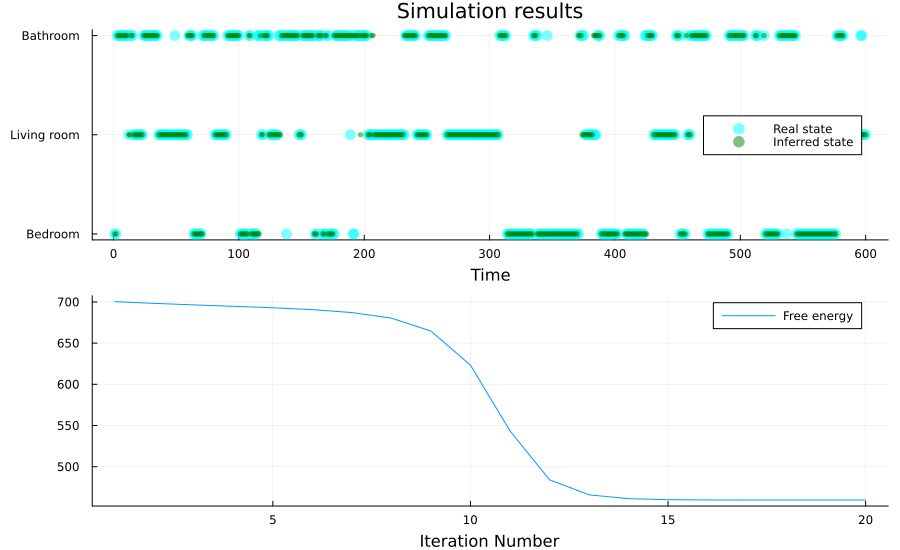

In [26]:
p1 = scatter(argmax.(_s̃s),
    title="Simulation results", 
    label="Real state", 
    legend=:right,
    xlabel="Time" ,
    yticks=([1,2,3],["Bedroom","Living room","Bathroom"]),
    markercolor=:cyan,
    markersize=6,
    markerstrokewidth=0,
    alpha=.5,
    size=(900,550)
)
p1 = scatter!(p1, argmax.(ReactiveMP.probvec.(_result.posteriors[:s])),
    label="Inferred state",
    markercolor=:green,
    markersize=3,
    markerstrokewidth=0,
    alpha=.5
)
p2 = plot(_result.free_energy, 
    label="Free energy",
    xlabel="Iteration Number"
)
plot(p1, p2, layout=@layout([ a; b ]))